In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
import os
import pywt  # 匯入小波轉換套件

# ==========================================
# 1. 小波去噪與核心數據處理函數
# ==========================================

def wavelet_denoising(data, wavelet='db4', level=2):
    """
    使用離散小波轉換 (DWT) 進行訊號去噪。
    對應小論文中：選用 Daubechies 4 (db4) 與二層分解，並以啟發式閾值濾除高頻雜訊。
    """
    # 1. 多尺度分解
    coeffs = pywt.wavedec(data, wavelet, mode='symmetric', level=level)

    # 2. 啟發式閾值計算 (利用最後一層高頻係數估計雜訊標準差)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(data)))

    # 3. 濾除高頻細節 (軟閾值處理)
    coeffs_thresholded = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs[1:]]

    # 4. 信號重構
    data_denoised = pywt.waverec(coeffs_thresholded, wavelet, mode='symmetric')

    # 確保重構後的長度與原始資料一致
    return data_denoised[:len(data)]

def load_and_preprocess_bridge_data(filepath, resample_freq='5min', neutral_axis_baseline=207):
    """載入數據、重採樣、小波去噪並計算基準偏移量"""
    print(f"正在載入橋梁數據: {filepath}...")
    try:
        df = pd.read_csv(filepath, low_memory=False)
        df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
        df = df.dropna(subset=[df.columns[0]])
        df.set_index(df.columns[0], inplace=True)

        cols_to_drop = [c for c in df.columns if '理論' in str(c) or 'Unnamed' in str(c)]
        df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

        df.rename(columns={df.columns[0]: 'Value'}, inplace=True)
        df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
        df = df[['Value']].dropna()
        df.sort_index(inplace=True)
        df = df[~df.index.duplicated(keep='last')]

        # 1. 重採樣與線性插值
        df_resampled = df.resample(resample_freq).mean()
        df_resampled['Value'] = df_resampled['Value'].interpolate(method='time', limit_direction='both')

        # 2. 應用小波去噪 (濾除高頻環境雜訊)
        raw_values = df_resampled['Value'].values
        denoised_values = wavelet_denoising(raw_values, wavelet='db4', level=2)
        df_resampled['Value'] = denoised_values

        # 3. 計算相對於中性軸的偏移量 (Offset)
        df_resampled['offset'] = df_resampled['Value'] - neutral_axis_baseline
        df_resampled.dropna(inplace=True)

        return df_resampled
    except Exception as e:
        print(f"讀取或處理失敗: {e}")
        raise

def create_advanced_features(df):
    """建立週期性時間特徵與滯後特徵"""
    df_feat = df.copy()
    df_feat['hour'] = df_feat.index.hour
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24.0)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24.0)
    df_feat['dayofweek'] = df_feat.index.dayofweek

    lags = [1, 2, 3, 24]
    for lag in lags:
        df_feat[f'offset_lag_{lag}'] = df_feat['offset'].shift(lag)

    df_feat.dropna(inplace=True)
    df_feat.drop(columns=['hour'], inplace=True)
    return df_feat

def create_sequences(data, seq_length, prediction_window=1, target_col_idx=0):
    """建立深度學習用的滑動視窗序列"""
    xs, ys = [], []
    for i in range(len(data) - seq_length - prediction_window + 1):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length : i + seq_length + prediction_window, target_col_idx]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


In [6]:
# ==========================================
# 2. 雙軌深度學習模型定義 (PyTorch)
# ==========================================

class LSTMAutoencoder(nn.Module):
    """路徑二：LSTM Autoencoder (用於學習健康指紋與重構誤差)"""
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(input_size=n_features, hidden_size=embedding_dim, num_layers=1, batch_first=True)
        self.decoder = nn.LSTM(input_size=embedding_dim, hidden_size=embedding_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        _, (hidden_n, _) = self.encoder(x)
        hidden_n = hidden_n.permute(1, 0, 2)
        decoder_input = hidden_n.repeat(1, self.seq_len, 1)
        decoder_output, _ = self.decoder(decoder_input)
        return self.output_layer(decoder_output)

class ForecastingLSTM(nn.Module):
    """路徑一：Forecasting LSTM (用於點對點時序預測)"""
    def __init__(self, input_size, hidden_size=64):
        super(ForecastingLSTM, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        return self.fc(x[:, -1, :])


In [7]:
# ==========================================
# 3. 提早停止 (Early Stopping) 訓練模組
# ==========================================

def train_ae_model_with_early_stopping(model, train_loader, val_loader, epochs, lr, device, patience=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"\n[訓練開始] LSTM-AE (目標 Epochs: {epochs}, Patience: {patience})...")
    for epoch in range(epochs):
        # 訓練階段
        model.train()
        train_loss = 0
        for batch_x, in train_loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()
            reconstruction = model(batch_x)
            loss = criterion(reconstruction, batch_x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # 驗證階段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, in val_loader:
                batch_x = batch_x.to(device)
                reconstruction = model(batch_x)
                loss = criterion(reconstruction, batch_x)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train MSE: {avg_train_loss:.6f} | Val MSE: {avg_val_loss:.6f}')

        # 提早停止判斷
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_ae_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⚠️ LSTM-AE 觸發提早停止 (Early Stopping) 於 Epoch {epoch+1}")
                break

    if os.path.exists('best_ae_model.pth'):
        model.load_state_dict(torch.load('best_ae_model.pth', weights_only=True))

def get_reconstruction_errors(model, data_loader, device):
    model.eval()
    errors = []
    criterion = nn.L1Loss(reduction='none') # MAE
    with torch.no_grad():
        for batch_x, in data_loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            loss = criterion(reconstruction, batch_x)
            sample_errors = loss.mean(dim=[1, 2]).cpu().numpy()
            errors.extend(sample_errors)
    return np.array(errors)


In [8]:
# ==========================================
# 4. 主流程：資料準備
# ==========================================

BRIDGE_FILE_PATH = 'bridge.csv' # 若檔名不同請在此修改
df_base = load_and_preprocess_bridge_data(BRIDGE_FILE_PATH)
df_final = create_advanced_features(df_base)

features = [col for col in df_final.columns if col != 'Value']
offset_idx = features.index('offset')

train_size = int(len(df_final) * 0.8)
train_df = df_final[features].iloc[:train_size]
test_df = df_final[features].iloc[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

SEQ_LENGTH = 24
X_train_seq, y_train_seq = create_sequences(train_scaled, SEQ_LENGTH, target_col_idx=offset_idx)
X_test_seq, y_test_seq = create_sequences(test_scaled, SEQ_LENGTH, target_col_idx=offset_idx)
test_timestamps = test_df.index[SEQ_LENGTH:]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n使用運算裝置: {device}")

X_train_tensor = torch.FloatTensor(X_train_seq)
X_test_tensor = torch.FloatTensor(X_test_seq)
y_train_tensor = torch.FloatTensor(y_train_seq).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test_seq).view(-1, 1)

BATCH_SIZE = 64

# DataLoader
ae_train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
ae_test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test_tensor), batch_size=BATCH_SIZE, shuffle=False)
fc_train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
fc_test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)


正在載入橋梁數據: bridge.csv...


/usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)



使用運算裝置: cpu


In [9]:
# ==========================================
# 5. 訓練路徑二：LSTM Autoencoder
# ==========================================
n_features = X_train_seq.shape[2]
ae_model = LSTMAutoencoder(seq_len=SEQ_LENGTH, n_features=n_features, embedding_dim=32).to(device)

train_ae_model_with_early_stopping(
    model=ae_model, train_loader=ae_train_loader, val_loader=ae_test_loader,
    epochs=50, lr=0.001, device=device, patience=10
)

train_errors = get_reconstruction_errors(ae_model, ae_train_loader, device)
test_errors = get_reconstruction_errors(ae_model, ae_test_loader, device)
mu, sigma = np.mean(train_errors), np.std(train_errors)
L1_threshold = mu + 2 * sigma
L2_threshold = mu + 3 * sigma
L3_threshold = mu + 5 * sigma
ae_errors = test_errors



[訓練開始] LSTM-AE (目標 Epochs: 50, Patience: 10)...
Epoch [1/50] | Train MSE: 0.005868 | Val MSE: 0.002708
Epoch [5/50] | Train MSE: 0.001042 | Val MSE: 0.001164
Epoch [10/50] | Train MSE: 0.000767 | Val MSE: 0.000929
Epoch [15/50] | Train MSE: 0.000655 | Val MSE: 0.000778
Epoch [20/50] | Train MSE: 0.000558 | Val MSE: 0.000659
Epoch [25/50] | Train MSE: 0.000474 | Val MSE: 0.000620
Epoch [30/50] | Train MSE: 0.000427 | Val MSE: 0.000527
Epoch [35/50] | Train MSE: 0.000399 | Val MSE: 0.000499
Epoch [40/50] | Train MSE: 0.000383 | Val MSE: 0.000478
Epoch [45/50] | Train MSE: 0.000366 | Val MSE: 0.000458
Epoch [50/50] | Train MSE: 0.000352 | Val MSE: 0.000438


In [10]:
# ==========================================
# 6. 訓練路徑一：Forecasting LSTM
# ==========================================
forecast_model = ForecastingLSTM(input_size=n_features).to(device)
criterion_forecast = nn.MSELoss()
optimizer_forecast = optim.Adam(forecast_model.parameters(), lr=0.001)

print(f"\n[訓練開始] Forecasting LSTM (目標 Epochs: 50, Patience: 10)...")
best_fc_val_loss = float('inf')
patience_counter_fc = 0

for epoch in range(50):
    forecast_model.train()
    train_loss = 0
    for batch_x, batch_y in fc_train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer_forecast.zero_grad()
        predictions = forecast_model(batch_x)
        loss = criterion_forecast(predictions, batch_y)
        loss.backward()
        optimizer_forecast.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(fc_train_loader)

    forecast_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in fc_test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = forecast_model(batch_x)
            loss = criterion_forecast(predictions, batch_y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(fc_test_loader)

    if (epoch+1) % 5 == 0 or epoch == 0:
         print(f'Epoch [{epoch+1}/50] | Train MSE: {avg_train_loss:.6f} | Val MSE: {avg_val_loss:.6f}')

    if avg_val_loss < best_fc_val_loss:
        best_fc_val_loss = avg_val_loss
        patience_counter_fc = 0
        torch.save(forecast_model.state_dict(), 'best_fc_model.pth')
    else:
        patience_counter_fc += 1
        if patience_counter_fc >= 10:
            print(f"⚠️ Forecasting LSTM 觸發提早停止 (Early Stopping) 於 Epoch {epoch+1}")
            break

if os.path.exists('best_fc_model.pth'):
    forecast_model.load_state_dict(torch.load('best_fc_model.pth', weights_only=True))

# 批次預測與計算殘差
forecast_model.eval()
test_preds_list = []
with torch.no_grad():
    for batch_x, _ in fc_test_loader:
        batch_x = batch_x.to(device)
        preds = forecast_model(batch_x)
        test_preds_list.extend(preds.cpu().numpy())

test_preds = np.array(test_preds_list)
y_test_actual = y_test_seq.reshape(-1, 1)
forecast_errors = np.abs(test_preds - y_test_actual).flatten()
forecast_threshold = np.percentile(forecast_errors, 95)

# --- 輸出模型效能指標 (小論文用) ---
rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds))
r2 = r2_score(y_test_actual, test_preds)
mae = mean_absolute_error(y_test_actual, test_preds)
print(f"\n📊 Forecasting LSTM 模型效能總結:")
print(f"RMSE: {rmse:.6f} | MAE: {mae:.6f} | R2 Score: {r2:.6f}")



[訓練開始] Forecasting LSTM (目標 Epochs: 50, Patience: 10)...
Epoch [1/50] | Train MSE: 0.003554 | Val MSE: 0.002378
Epoch [5/50] | Train MSE: 0.001808 | Val MSE: 0.002111
Epoch [10/50] | Train MSE: 0.001595 | Val MSE: 0.001939
Epoch [15/50] | Train MSE: 0.001529 | Val MSE: 0.001845
Epoch [20/50] | Train MSE: 0.001504 | Val MSE: 0.001837
Epoch [25/50] | Train MSE: 0.001488 | Val MSE: 0.001847
Epoch [30/50] | Train MSE: 0.001472 | Val MSE: 0.001815
Epoch [35/50] | Train MSE: 0.001463 | Val MSE: 0.001799
Epoch [40/50] | Train MSE: 0.001451 | Val MSE: 0.001831
⚠️ Forecasting LSTM 觸發提早停止 (Early Stopping) 於 Epoch 42

📊 Forecasting LSTM 模型效能總結:
RMSE: 0.042301 | MAE: 0.023033 | R2 Score: 0.821450


/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 27083 (\N{CJK UNIFIED IDEOGRAPH-69CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5651/1782485814.py:40: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}

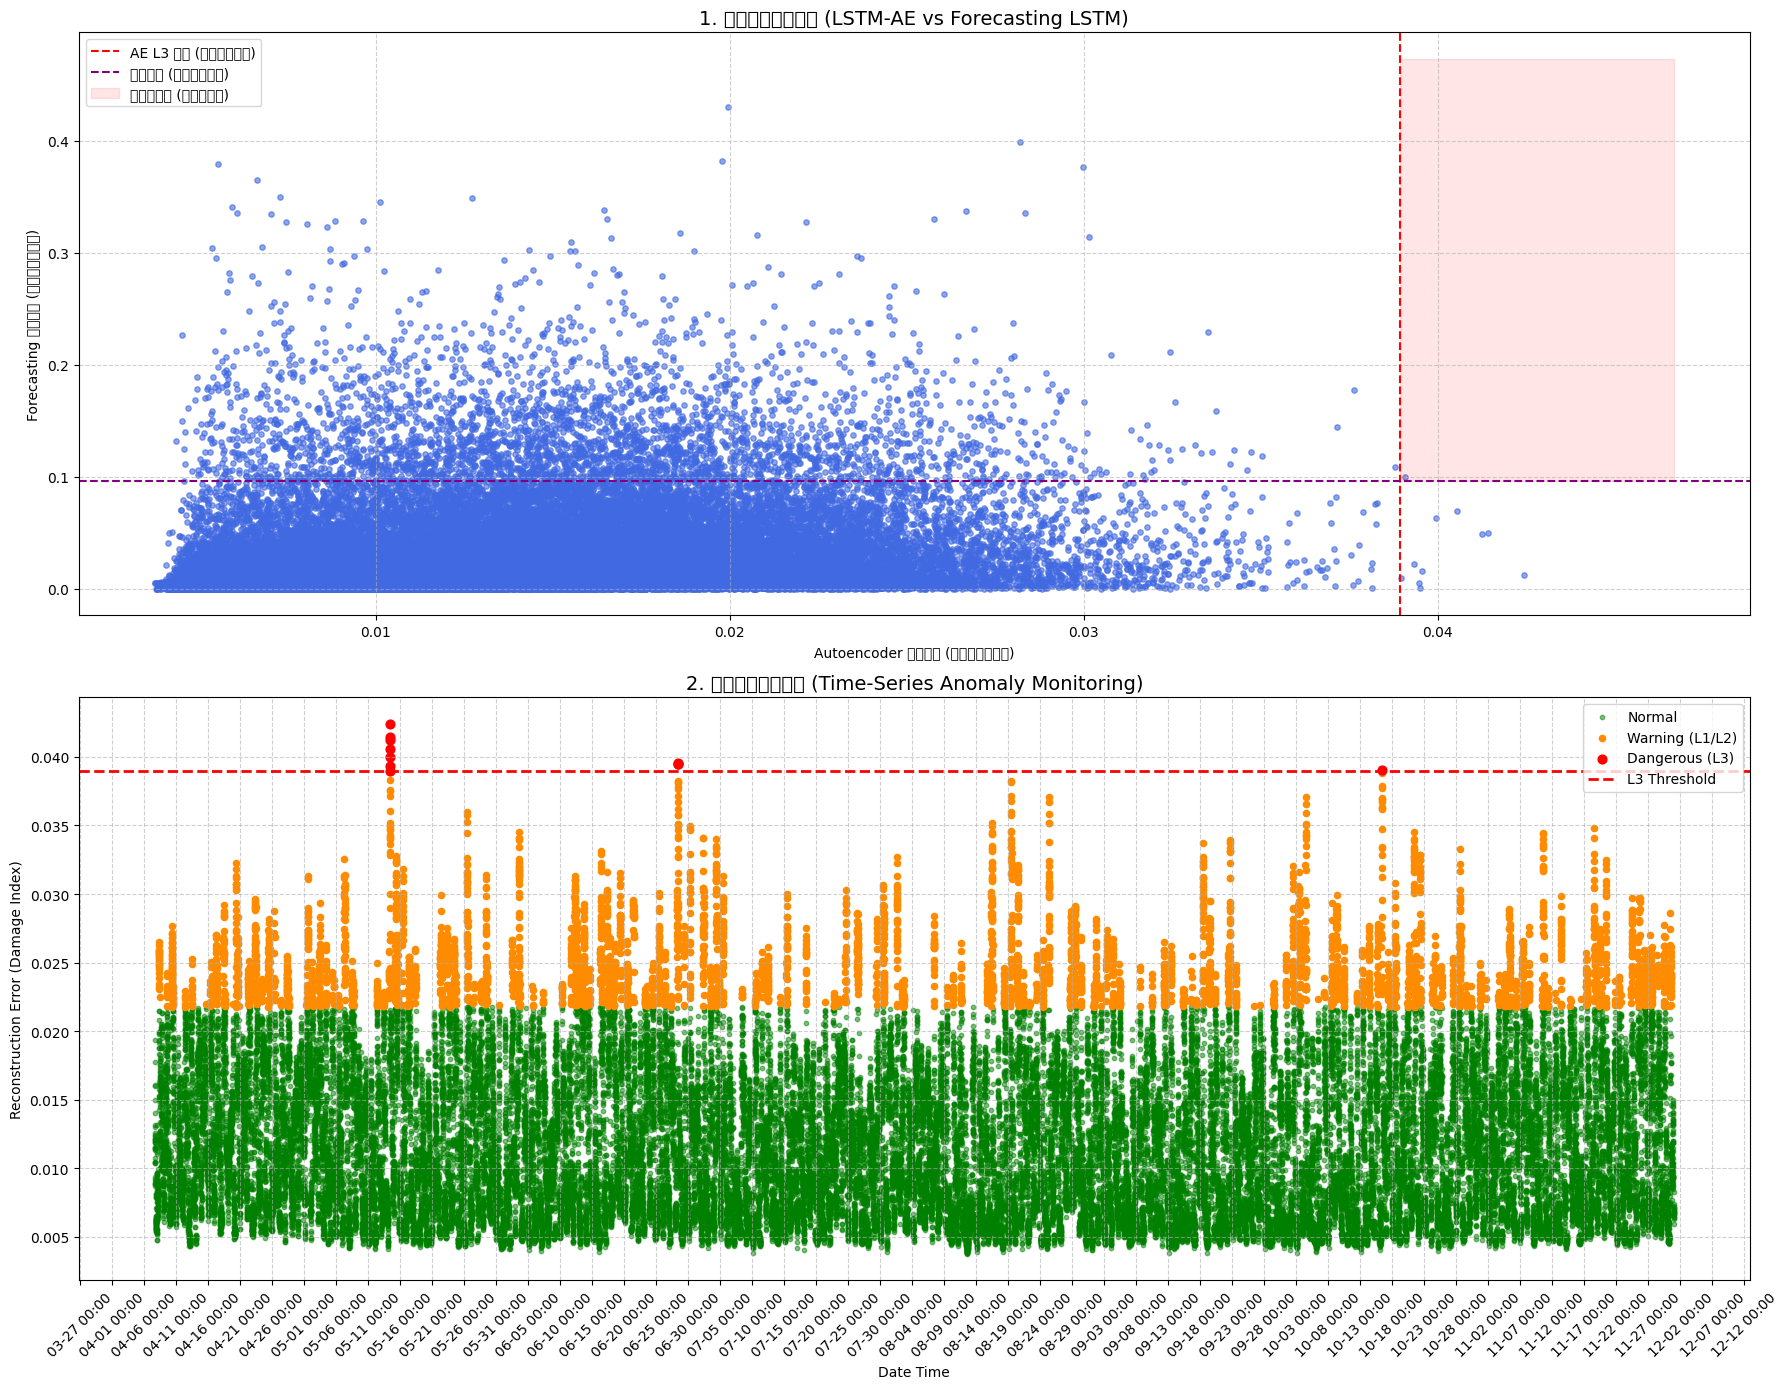

In [11]:
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')
# ==========================================
# 7. 繪製雙軌預警儀表板
# ==========================================
plt.figure(figsize=(18, 14))
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 指定微軟正黑體
plt.rcParams['axes.unicode_minus'] = False

# [圖 A] 雙模型交叉驗證散佈圖
plt.subplot(2, 1, 1)
plt.scatter(ae_errors, forecast_errors, alpha=0.6, color='royalblue', s=15)
plt.axvline(L3_threshold, color='red', linestyle='--', label='AE L3 門檻 (整體行為異常)')
plt.axhline(forecast_threshold, color='purple', linestyle='--', label='預測門檻 (瞬時數值異常)')
plt.fill_between([L3_threshold, max(ae_errors)*1.1], forecast_threshold, max(forecast_errors)*1.1, color='red', alpha=0.1, label='雙軌皆報警 (極高置信度)')
plt.title('1. 雙軌模型交叉驗證 (LSTM-AE vs Forecasting LSTM)', fontsize=14)
plt.xlabel('Autoencoder 重建誤差 (結構行為異常度)')
plt.ylabel('Forecasting 預測誤差 (瞬時數值異常度)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# [圖 B] 加入真實時間戳的綜合預警圖
plt.subplot(2, 1, 2)
normal_idx = np.where(ae_errors < L1_threshold)[0]
warning_idx = np.where((ae_errors >= L1_threshold) & (ae_errors < L3_threshold))[0]
l3_idx = np.where(ae_errors >= L3_threshold)[0]

plt.scatter(test_timestamps[normal_idx], ae_errors[normal_idx], color='green', s=10, label='Normal', alpha=0.5)
plt.scatter(test_timestamps[warning_idx], ae_errors[warning_idx], color='darkorange', s=20, label='Warning (L1/L2)')
plt.scatter(test_timestamps[l3_idx], ae_errors[l3_idx], color='red', s=40, label='Dangerous (L3)')
plt.axhline(L3_threshold, color='red', linestyle='--', linewidth=2, label='L3 Threshold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45)
plt.title('2. 時間序列異常監測 (Time-Series Anomaly Monitoring)', fontsize=14)
plt.xlabel('Date Time')
plt.ylabel('Reconstruction Error (Damage Index)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import os

# ==========================================
# [準備工作] 解決 Colab 中文亂碼並設定學術繪圖風格
# ==========================================
# 下載開源字體 (若已下載會自動覆蓋)
os.system('wget -O TaipeiSansTCBeta-Regular.ttf "https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download"')
fm.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['TaipeiSans TC Beta', 'Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
# 設定字體大小，符合學術論文易讀性
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 14})

# 建立資料夾存放要放入論文的圖片
if not os.path.exists('paper_figures'):
    os.makedirs('paper_figures')

# ==========================================
# 圖 1：模型訓練收斂曲線 (使用 AE 的訓練誤差作範例)
# 論文放置點：4.4 或 5.1 模型訓練結果
# ==========================================
# (註：為了畫出這張圖，假設您在訓練 AE 時有收集 history。
# 若無，此段僅為示意，您可以直接跳過圖 1 或使用之前印出的數據)
'''
plt.figure(figsize=(10, 6))
plt.plot(ae_loss_history, label='Train Loss (MSE)', color='blue', linewidth=2)
plt.title('Figure 1. LSTM Autoencoder 模型訓練收斂曲線')
plt.xlabel('訓練輪數 (Epochs)')
plt.ylabel('均方誤差 (MSE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('paper_figures/Fig1_Convergence.png', dpi=300)
plt.show()
'''

# ==========================================
# 圖 2：AE 重建誤差分佈與 L1/L2/L3 預警門檻
# 論文放置點：5.2 異常門檻設定與統計分析
# ==========================================
plt.figure(figsize=(12, 6))
sns.histplot(train_errors, bins=60, color='royalblue', alpha=0.6, label='健康狀態分佈 (Train)', kde=True)

# 畫出預警門檻線
plt.axvline(L1_threshold, color='gold', linestyle='--', linewidth=2.5, label=f'L1 注意 (μ+2σ): {L1_threshold:.3f}')
plt.axvline(L2_threshold, color='darkorange', linestyle='--', linewidth=2.5, label=f'L2 警告 (μ+3σ): {L2_threshold:.3f}')
plt.axvline(L3_threshold, color='red', linestyle='--', linewidth=2.5, label=f'L3 危險 (μ+5σ): {L3_threshold:.3f}')

plt.title('Figure 2. 結構健康特徵之重建誤差分佈與動態預警門檻')
plt.xlabel('重建誤差 (Reconstruction Error - MAE)')
plt.ylabel('樣本數量 (Frequency)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('paper_figures/Fig2_Error_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 圖 3：Forecasting LSTM 實際觀測值與模型預測值對比圖
# 論文放置點：5.4.1 預測路徑結果分析
# ==========================================
plt.figure(figsize=(15, 6))
# 為了讓圖表清晰，我們擷取測試集前 400 筆資料 (約 33 小時的變化)
display_range = 400

plt.plot(test_timestamps[:display_range], y_test_actual[:display_range], label='真實觀測值 (Actual)', color='royalblue', linewidth=2)
plt.plot(test_timestamps[:display_range], test_preds[:display_range], label='模型預測值 (Predicted)', color='crimson', linestyle='--', linewidth=2)

plt.title('Figure 3. Forecasting LSTM 實際觀測值與模型預測軌跡對比 (前400筆時序)')
plt.xlabel('時間 (Date Time)')
plt.ylabel('斜面高度偏移量 (Offset)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('paper_figures/Fig3_Actual_vs_Predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 圖 4：雙軌交叉驗證散佈圖 (論文技術核心亮點)
# 論文放置點：5.4.2 雙軌模型交叉驗證與討論
# ==========================================
plt.figure(figsize=(10, 8))
plt.scatter(ae_errors, forecast_errors, alpha=0.6, color='royalblue', s=20, edgecolors='none')

# 畫出雙軌的異常門檻線
plt.axvline(L3_threshold, color='red', linestyle='--', linewidth=2, label='AE 結構行為危險門檻 (L3)')
plt.axhline(forecast_threshold, color='purple', linestyle='--', linewidth=2, label='LSTM 瞬時數值異常門檻')

# 標示出「雙軌皆報警」的危險區域
plt.fill_between([L3_threshold, max(ae_errors)*1.1],
                 forecast_threshold, max(forecast_errors)*1.1,
                 color='red', alpha=0.15, label='雙軌報警區 (極高置信度異常)')

plt.title('Figure 4. 預測路徑與重構路徑之雙軌交叉驗證散佈圖')
plt.xlabel('Autoencoder 重建誤差 (結構長期異常度)')
plt.ylabel('Forecasting 預測誤差 (瞬時突發異常度)')
plt.xlim(left=0, right=max(ae_errors)*1.1)
plt.ylim(bottom=0, top=max(forecast_errors)*1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('paper_figures/Fig4_Cross_Validation.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 圖 5：時間序列綜合異常監測圖 (戰情室儀表板視角)
# 論文放置點：結論與未來實務應用
# ==========================================
plt.figure(figsize=(15, 6))

# 找出各個預警級別的索引
normal_idx = np.where(ae_errors < L1_threshold)[0]
warning_idx = np.where((ae_errors >= L1_threshold) & (ae_errors < L3_threshold))[0]
l3_idx = np.where(ae_errors >= L3_threshold)[0]

# 繪製散佈圖點位
plt.scatter(test_timestamps[normal_idx], ae_errors[normal_idx], color='mediumseagreen', s=15, label='正常狀態 (Normal)', alpha=0.7)
plt.scatter(test_timestamps[warning_idx], ae_errors[warning_idx], color='darkorange', s=30, label='注意/警告 (L1/L2)', alpha=0.8)
plt.scatter(test_timestamps[l3_idx], ae_errors[l3_idx], color='red', s=50, label='危險異常 (L3)', zorder=5)

# 畫出背景警示色塊以利識別
plt.axhspan(0, L1_threshold, facecolor='lightgreen', alpha=0.1)
plt.axhspan(L1_threshold, L3_threshold, facecolor='orange', alpha=0.1)
plt.axhspan(L3_threshold, max(ae_errors)*1.1, facecolor='red', alpha=0.1)

# L3 門檻線
plt.axhline(L3_threshold, color='red', linestyle='--', linewidth=2)

plt.title('Figure 5. 石灼橋時間序列綜合異常監測儀表板')
plt.xlabel('時間 (Date Time)')
plt.ylabel('重建誤差 / 損害指數 (Damage Index)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5)) # 每 5 天顯示一個刻度
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('paper_figures/Fig5_TimeSeries_Monitor.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 所有小論文圖表已繪製完畢！")
print("📁 圖片已自動以 300 DPI 高畫質儲存於 Colab 的 'paper_figures' 資料夾中。")